# 🌿 CSIRO Biomass Training - RunPod版 v2

## 🚀 実行手順
1. セル1.1: GPU確認 & パッケージインストール
2. セル2.1-2.3: Kaggle API設定 & データダウンロード
3. セル3.1: 全ての定義（Import, Model, Dataset, Training）
4. セル4.1-4.2: データ読み込み & 学習開始

---

## 1. 🔧 Environment Setup

In [1]:
#@title 1.1 Check GPU & Install Packages

# GPU確認
!nvidia-smi

# パッケージインストール（必要なもの全て）
!pip install -q timm>=1.0.0 albumentations kaggle pandas scikit-learn opencv-python-headless matplotlib tqdm unzip

import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU: {gpu} ({vram:.1f} GB)")

import timm
print(f"timm: {timm.__version__}")

# モデル確認（list_pretrained を使用）
model_name = "vit_huge_plus_patch16_dinov3.lvd1689m"
available = model_name in timm.list_pretrained()
print(f"{model_name}: {'✅' if available else '❌'}")

# 他のパッケージ確認
import pandas as pd
import sklearn
import cv2
import albumentations
print(f"pandas: {pd.__version__} ✅")
print(f"sklearn: {sklearn.__version__} ✅")
print(f"cv2: {cv2.__version__} ✅")
print(f"albumentations: {albumentations.__version__} ✅")


Sun Jan 25 13:52:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               On  |   00000000:8D:00.0 Off |                  Off |
| 30%   39C    P8             14W /  230W |       2MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. 📁 Kaggle API & Dataset

### kaggle.json の設定方法
1. https://www.kaggle.com/settings → API → Create New API Token
2. ダウンロードした `kaggle.json` を JupyterLab にアップロード
3. セル2.2 を実行

In [2]:
#@title 2.1 Check Kaggle API Status
import os

kaggle_dir = os.path.expanduser("~/.kaggle")
kaggle_json = os.path.join(kaggle_dir, "kaggle.json")

if os.path.exists(kaggle_json):
    print("✅ Kaggle API already configured")
else:
    print("❌ kaggle.json が見つかりません")
    print("")
    print("📤 kaggle.json をアップロードしてください:")
    print("   1. JupyterLabの左パネルからファイルをアップロード")
    print("   2. 次のセル（2.2）を実行")


❌ kaggle.json が見つかりません

📤 kaggle.json をアップロードしてください:
   1. JupyterLabの左パネルからファイルをアップロード
   2. 次のセル（2.2）を実行


In [3]:
#@title 2.2 Configure Kaggle API（kaggle.jsonアップロード後に実行）
import os
import shutil

kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

# ファイルを探して移動
kaggle_json_dest = os.path.join(kaggle_dir, "kaggle.json")
found = False

# 検索する場所のリスト
search_paths = [
    "/workspace/kaggle.json",
    "kaggle.json",
    os.path.expanduser("~/kaggle.json"),
]

for path in search_paths:
    if os.path.exists(path):
        shutil.copy(path, kaggle_json_dest)
        os.chmod(kaggle_json_dest, 0o600)
        print(f"✅ Found and configured: {path}")
        found = True
        break

if not found and os.path.exists(kaggle_json_dest):
    print("✅ Kaggle API already configured")
    found = True

if found:
    # APIテスト
    import subprocess
    result = subprocess.run(["kaggle", "competitions", "list", "-s", "csiro"], 
                           capture_output=True, text=True)
    if result.returncode == 0:
        print("✅ API動作確認OK")
    else:
        print("❌ APIエラー")
        print(f"   {result.stderr}")
else:
    print("❌ kaggle.json が見つかりません")
    print("   JupyterLabにkaggle.jsonをアップロードしてから再実行してください")


✅ Found and configured: /workspace/kaggle.json
✅ API動作確認OK


In [4]:
#@title 2.3 Download Dataset
import os

DATA_DIR = "/workspace/csiro-biomass"
TRAIN_DIR = os.path.join(DATA_DIR, "train")

if os.path.exists(TRAIN_DIR) and len(os.listdir(TRAIN_DIR)) > 0:
    print(f"✅ Dataset already exists: {len(os.listdir(TRAIN_DIR))} images")
else:
    print("📥 Downloading dataset...")
    os.makedirs(DATA_DIR, exist_ok=True)
    
    !kaggle competitions download -c csiro-biomass -p /workspace/
    
    if os.path.exists("/workspace/csiro-biomass.zip"):
        print("📦 Extracting...")
        !unzip -q /workspace/csiro-biomass.zip -d {DATA_DIR}
        !rm /workspace/csiro-biomass.zip
        
        if os.path.exists(TRAIN_DIR):
            print(f"✅ Dataset ready: {len(os.listdir(TRAIN_DIR))} train images")
        else:
            print("❌ Extraction failed")
            !ls -la {DATA_DIR}
    else:
        print("❌ Download failed!")
        print("")
        print("⚠️ 以下を確認してください:")
        print("   1. kaggle.json が正しく設定されているか")
        print("   2. コンペのルールに同意しているか:")
        print("      https://www.kaggle.com/competitions/csiro-biomass/rules")


✅ Dataset already exists: 357 images


## 3. ⚙️ Training Setup

このセルで全ての定義を行います。

In [5]:
#@title 3.1 All Imports, Model, Dataset, and Training Functions

# ============================================================
# IMPORTS
# ============================================================
import os
import gc
import math
import random
import time
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Optional

import cv2
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from timm.utils import ModelEmaV2
from sklearn.model_selection import StratifiedGroupKFold
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ============================================================
# CONFIGURATION
# ============================================================
class CFG:
    TARGETS = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]
    N_FOLDS = 5
    BACKBONE = "vit_huge_plus_patch16_dinov3.lvd1689m"
    IMG_SIZE = 512
    
    # RunPod paths
    DATA_DIR = Path("/workspace/csiro-biomass")
    TRAIN_CSV = DATA_DIR / "train.csv"
    TRAIN_IMAGE_DIR = DATA_DIR / "train"
    CHECKPOINT_DIR = Path("/workspace/checkpoints")
    
    SEED = 42
    BATCH_SIZE = 2
    GRAD_ACC = 4
    NUM_WORKERS = 4
    EPOCHS = 30
    WARMUP_EPOCHS = 3
    PATIENCE = 5
    
    LR_BACKBONE = 5e-5
    LR_HEAD = 1e-4
    WD = 1e-2
    EMA_DECAY = 0.995
    
    LOSS_WEIGHTS = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
    R2_WEIGHTS = np.array([0.1, 0.1, 0.1, 0.2, 0.5])
    
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CFG.CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()

print("=" * 60)
print("📋 Configuration")
print("=" * 60)
print(f"N_FOLDS     = {CFG.N_FOLDS}")
print(f"BACKBONE    = {CFG.BACKBONE}")
print(f"BATCH_SIZE  = {CFG.BATCH_SIZE} x {CFG.GRAD_ACC} = {CFG.BATCH_SIZE * CFG.GRAD_ACC}")
print(f"DEVICE      = {CFG.DEVICE}")
print("-" * 60)
csv_ok = "✅" if CFG.TRAIN_CSV.exists() else "❌"
dir_ok = "✅" if CFG.TRAIN_IMAGE_DIR.exists() else "❌"
print(f"TRAIN_CSV   = {CFG.TRAIN_CSV} {csv_ok}")
print(f"TRAIN_DIR   = {CFG.TRAIN_IMAGE_DIR} {dir_ok}")
print(f"CKPT_DIR    = {CFG.CHECKPOINT_DIR} ✅")
print("=" * 60)

# ============================================================
# MODEL
# ============================================================
class LocalMambaBlock(nn.Module):
    def __init__(self, dim, kernel_size=5, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.dwconv = nn.Conv1d(dim, dim, kernel_size=kernel_size, padding=kernel_size//2, groups=dim)
        self.gate = nn.Linear(dim, dim)
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        shortcut = x
        x = self.norm(x)
        x = x * torch.sigmoid(self.gate(x))
        x = self.dwconv(x.transpose(1, 2)).transpose(1, 2)
        x = self.proj(x)
        return shortcut + self.drop(x)


class BiomassModel(nn.Module):
    def __init__(self, model_name, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool="")
        nf = self.backbone.num_features
        
        if hasattr(self.backbone, "set_grad_checkpointing"):
            self.backbone.set_grad_checkpointing(True)
            print("✅ Gradient Checkpointing enabled")
        
        self.fusion = nn.Sequential(
            LocalMambaBlock(nf, kernel_size=5, dropout=0.1),
            LocalMambaBlock(nf, kernel_size=5, dropout=0.1)
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        self.head_green = nn.Sequential(nn.Linear(nf, nf//2), nn.GELU(), nn.Dropout(0.2), nn.Linear(nf//2, 1), nn.Softplus())
        self.head_dead = nn.Sequential(nn.Linear(nf, nf//2), nn.GELU(), nn.Dropout(0.2), nn.Linear(nf//2, 1), nn.Softplus())
        self.head_clover = nn.Sequential(nn.Linear(nf, nf//2), nn.GELU(), nn.Dropout(0.2), nn.Linear(nf//2, 1), nn.Softplus())

    def forward(self, x):
        left, right = x
        x_l = self.backbone(left)
        x_r = self.backbone(right)
        x = self.fusion(torch.cat([x_l, x_r], dim=1))
        x = self.pool(x.transpose(1, 2)).flatten(1)
        green = self.head_green(x)
        dead = self.head_dead(x)
        clover = self.head_clover(x)
        gdm = green + clover
        total = green + clover + dead
        return torch.cat([green, dead, clover, gdm, total], dim=1)

print("✅ Model defined")

# ============================================================
# DATASET & TRANSFORMS
# ============================================================
class BiomassDataset(Dataset):
    def __init__(self, df, transforms, image_dir):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.image_dir = Path(image_dir)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.image_dir / Path(row["image_path"]).name
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        left = img[:, :w//2]
        right = img[:, w//2:]
        
        if self.transforms:
            seed = random.randint(0, 99999)
            random.seed(seed)
            np.random.seed(seed)
            left = self.transforms(image=left)["image"]
            random.seed(seed)
            np.random.seed(seed)
            right = self.transforms(image=right)["image"]
        
        labels = torch.tensor([row[t] for t in CFG.TARGETS], dtype=torch.float32)
        return left, right, labels


def get_train_transforms():
    return A.Compose([
        A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.5),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


def get_val_transforms():
    return A.Compose([
        A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

print("✅ Dataset & Transforms defined")

# ============================================================
# LOSS & METRICS
# ============================================================
def biomass_loss(outputs, labels, weights=None):
    losses = nn.SmoothL1Loss(reduction="none", beta=5.0)(outputs, labels).mean(dim=0)
    if weights is None:
        return losses.mean()
    w = torch.as_tensor(weights, device=losses.device, dtype=losses.dtype)
    return (losses * w / w.sum()).sum()


def weighted_r2_score(y_true, y_pred):
    r2s = []
    for i in range(y_true.shape[1]):
        ss_res = np.sum((y_true[:, i] - y_pred[:, i]) ** 2)
        ss_tot = np.sum((y_true[:, i] - np.mean(y_true[:, i])) ** 2)
        r2s.append(1 - ss_res / ss_tot if ss_tot > 0 else 0.0)
    r2s = np.array(r2s)
    return np.sum(r2s * CFG.R2_WEIGHTS) / np.sum(CFG.R2_WEIGHTS), r2s

print("✅ Loss & Metrics defined")

# ============================================================
# TRAINING FUNCTIONS
# ============================================================
scaler = torch.cuda.amp.GradScaler()


def train_epoch(model, loader, optimizer, device, ema=None):
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    pbar = tqdm(loader, desc="Train", leave=False)
    
    for i, (left, right, labels) in enumerate(pbar):
        left = left.to(device)
        right = right.to(device)
        labels = labels.to(device)
        
        with torch.cuda.amp.autocast():
            outputs = model((left, right))
            loss = biomass_loss(outputs, labels, CFG.LOSS_WEIGHTS) / CFG.GRAD_ACC
        
        scaler.scale(loss).backward()
        total_loss += loss.item() * left.size(0) * CFG.GRAD_ACC
        
        if (i + 1) % CFG.GRAD_ACC == 0 or (i + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            if ema:
                ema.update(model)
            optimizer.zero_grad()
        
        pbar.set_postfix({"loss": f"{loss.item() * CFG.GRAD_ACC:.4f}"})
    
    return total_loss / len(loader.dataset)


@torch.no_grad()
def valid_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for left, right, labels in tqdm(loader, desc="Valid", leave=False):
        left = left.to(device)
        right = right.to(device)
        labels = labels.to(device)
        
        with torch.cuda.amp.autocast():
            outputs = model((left, right))
            loss = biomass_loss(outputs, labels, CFG.LOSS_WEIGHTS)
        
        total_loss += loss.item() * left.size(0)
        all_preds.append(outputs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    
    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    r2, per_r2 = weighted_r2_score(labels, preds)
    return total_loss / len(loader.dataset), r2, per_r2


def build_optimizer(model):
    backbone_ids = {id(p) for p in model.backbone.parameters()}
    backbone_params = [p for p in model.parameters() if p.requires_grad and id(p) in backbone_ids]
    head_params = [p for p in model.parameters() if p.requires_grad and id(p) not in backbone_ids]
    return optim.AdamW([
        {"params": backbone_params, "lr": CFG.LR_BACKBONE, "weight_decay": CFG.WD},
        {"params": head_params, "lr": CFG.LR_HEAD, "weight_decay": CFG.WD},
    ])


def build_scheduler(optimizer, num_epochs):
    def lr_lambda(epoch):
        if epoch < CFG.WARMUP_EPOCHS:
            return (epoch + 1) / CFG.WARMUP_EPOCHS
        progress = (epoch - CFG.WARMUP_EPOCHS) / (num_epochs - CFG.WARMUP_EPOCHS)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return LambdaLR(optimizer, lr_lambda)

print("✅ Training functions defined")

# ============================================================
# MAIN TRAINING FUNCTION
# ============================================================
def train_fold(fold, df_wide):
    print(f"\n{'='*60}")
    print(f"🚀 FOLD {fold} / {CFG.N_FOLDS-1}")
    print(f"{'='*60}")
    
    # K-Fold split
    sgkf = StratifiedGroupKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
    splits = list(sgkf.split(df_wide, df_wide["State"], groups=df_wide["Sampling_Date"]))
    train_idx, val_idx = splits[fold]
    
    train_df = df_wide.iloc[train_idx].reset_index(drop=True)
    val_df = df_wide.iloc[val_idx].reset_index(drop=True)
    print(f"Train: {len(train_df)} | Val: {len(val_df)}")
    
    # Clear memory
    torch.cuda.empty_cache()
    gc.collect()
    
    # Datasets & Loaders
    train_ds = BiomassDataset(train_df, get_train_transforms(), CFG.TRAIN_IMAGE_DIR)
    val_ds = BiomassDataset(val_df, get_val_transforms(), CFG.TRAIN_IMAGE_DIR)
    
    train_loader = DataLoader(
        train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
        num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
        num_workers=CFG.NUM_WORKERS, pin_memory=True
    )
    
    # Model
    model = BiomassModel(CFG.BACKBONE, pretrained=True).to(CFG.DEVICE)
    ema = ModelEmaV2(model, decay=CFG.EMA_DECAY)
    optimizer = build_optimizer(model)
    scheduler = build_scheduler(optimizer, CFG.EPOCHS)
    
    # Training loop
    best_r2 = -float("inf")
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "val_r2": []}
    
    for epoch in range(CFG.EPOCHS):
        print(f"\nEpoch {epoch+1}/{CFG.EPOCHS}")
        
        train_loss = train_epoch(model, train_loader, optimizer, CFG.DEVICE, ema)
        scheduler.step()
        val_loss, val_r2, per_r2 = valid_epoch(ema.module, val_loader, CFG.DEVICE)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_r2"].append(val_r2)
        
        lr = optimizer.param_groups[0]["lr"]
        print(f"  Loss: {train_loss:.4f}/{val_loss:.4f} | R2: {val_r2:.4f} | LR: {lr:.2e}")
        print(f"  R2: G={per_r2[0]:.3f} D={per_r2[1]:.3f} C={per_r2[2]:.3f} GDM={per_r2[3]:.3f} T={per_r2[4]:.3f}")
        
        if val_r2 > best_r2:
            best_r2 = val_r2
            patience_counter = 0
            save_path = CFG.CHECKPOINT_DIR / f"best_model_fold{fold}.pth"
            torch.save(ema.module.state_dict(), save_path)
            print(f"  ✅ Saved: {save_path}")
        else:
            patience_counter += 1
            if patience_counter >= CFG.PATIENCE:
                print(f"\n⚠️ Early stopping at epoch {epoch+1}")
                break
    
    print(f"\n🏆 Fold {fold} Best R2: {best_r2:.4f}")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title(f"Fold {fold} Loss")
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(history["val_r2"], "g")
    axes[1].axhline(best_r2, color="r", linestyle="--", label=f"Best: {best_r2:.4f}")
    axes[1].set_title(f"Fold {fold} R2")
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(CFG.CHECKPOINT_DIR / f"fold{fold}_history.png", dpi=100)
    plt.show()
    
    # Cleanup
    del model, ema, optimizer, scheduler, train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()
    
    return best_r2

print("✅ train_fold function defined")
print("\n🎉 All definitions complete!")


📋 Configuration
N_FOLDS     = 5
BACKBONE    = vit_huge_plus_patch16_dinov3.lvd1689m
BATCH_SIZE  = 2 x 4 = 8
DEVICE      = cuda
------------------------------------------------------------
TRAIN_CSV   = /workspace/csiro-biomass/train.csv ✅
TRAIN_DIR   = /workspace/csiro-biomass/train ✅
CKPT_DIR    = /workspace/checkpoints ✅
✅ Model defined
✅ Dataset & Transforms defined
✅ Loss & Metrics defined
✅ Training functions defined
✅ train_fold function defined

🎉 All definitions complete!


## 4. 🚀 Run Training

全5 Foldを連続で学習します（約20時間）。
途中で止めても、保存済みのFoldはスキップされます。

In [6]:
#@title 4.1 Load Data
print("📊 Loading data...")

if not CFG.TRAIN_CSV.exists():
    print("❌ train.csv が見つかりません！")
    print("   セクション 2.3 を再実行してください")
else:
    df_long = pd.read_csv(CFG.TRAIN_CSV)
    df_wide = df_long.pivot(index="image_path", columns="target_name", values="target").reset_index()
    df_wide = df_wide[["image_path"] + CFG.TARGETS]
    meta = df_long[["image_path", "Sampling_Date", "State"]].drop_duplicates()
    df_wide = df_wide.merge(meta, on="image_path", how="left")
    
    print(f"✅ Loaded {len(df_wide)} images")
    print(f"   Columns: {list(df_wide.columns)}")
    
    # Check existing checkpoints
    print("\n📁 Existing checkpoints:")
    for fold in range(CFG.N_FOLDS):
        ckpt = CFG.CHECKPOINT_DIR / f"best_model_fold{fold}.pth"
        if ckpt.exists():
            size = ckpt.stat().st_size / 1024**3
            print(f"  ✅ Fold {fold}: {size:.2f} GB")
        else:
            print(f"  ❌ Fold {fold}: not found")


📊 Loading data...
✅ Loaded 357 images
   Columns: ['image_path', 'Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g', 'Sampling_Date', 'State']

📁 Existing checkpoints:
  ❌ Fold 0: not found
  ❌ Fold 1: not found
  ❌ Fold 2: not found
  ❌ Fold 3: not found
  ❌ Fold 4: not found


🚀 STARTING TRAINING - ALL 5 FOLDS

⏰ Estimated time: ~20 hours
💰 Estimated cost: ~$8-15 (RTX 4090/A5000)


🚀 FOLD 0 / 4
Train: 286 | Val: 71


model.safetensors:   0%|          | 0.00/3.36G [00:00<?, ?B/s]

✅ Gradient Checkpointing enabled

Epoch 1/30


Train:   0%|          | 0/143 [00:00<?, ?it/s]

Valid:   0%|          | 0/36 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/36 [00:00<?, ?it/s]

  Loss: 0.5509/5.7421 | R2: 0.6499 | LR: 1.69e-07
  R2: G=0.747 D=0.432 C=0.560 GDM=0.785 T=0.638
  ✅ Saved: /workspace/checkpoints/best_model_fold0.pth

Epoch 30/30


Train:   0%|          | 0/143 [00:00<?, ?it/s]

Valid:   0%|          | 0/36 [00:00<?, ?it/s]

  Loss: 0.4842/5.7455 | R2: 0.6500 | LR: 0.00e+00
  R2: G=0.746 D=0.433 C=0.562 GDM=0.785 T=0.638
  ✅ Saved: /workspace/checkpoints/best_model_fold0.pth

🏆 Fold 0 Best R2: 0.6500


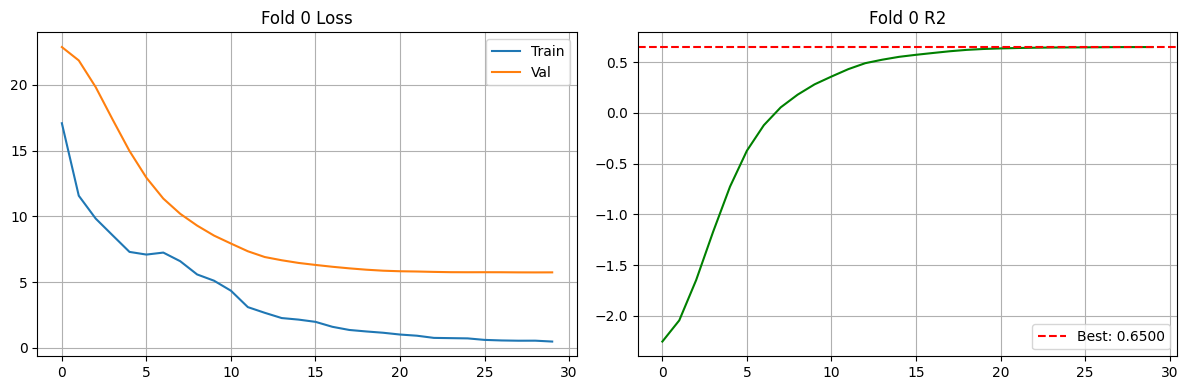


⏱️ Fold 0 completed in 1.79 hours

🚀 FOLD 1 / 4
Train: 294 | Val: 63
✅ Gradient Checkpointing enabled

Epoch 1/30


Train:   0%|          | 0/147 [00:00<?, ?it/s]

Valid:   0%|          | 0/32 [00:00<?, ?it/s]

  Loss: 17.2461/19.5967 | R2: -1.1180 | LR: 3.33e-05
  R2: G=-0.846 D=-1.471 C=-0.039 GDM=-0.908 T=-1.402
  ✅ Saved: /workspace/checkpoints/best_model_fold1.pth

Epoch 2/30


Train:   0%|          | 0/147 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/32 [00:00<?, ?it/s]

  Loss: 0.5278/6.8130 | R2: 0.3765 | LR: 1.69e-07
  R2: G=0.603 D=0.476 C=-1.639 GDM=0.572 T=0.636

Epoch 30/30


Train:   0%|          | 0/147 [00:00<?, ?it/s]

Valid:   0%|          | 0/32 [00:00<?, ?it/s]

  Loss: 0.5195/6.8064 | R2: 0.3786 | LR: 0.00e+00
  R2: G=0.605 D=0.475 C=-1.627 GDM=0.574 T=0.637

🏆 Fold 1 Best R2: 0.3823


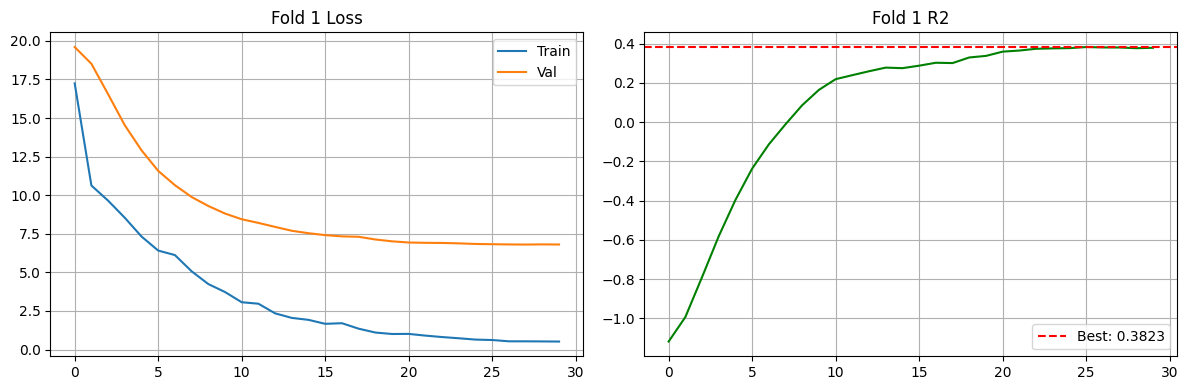


⏱️ Fold 1 completed in 1.79 hours

🚀 FOLD 2 / 4
Train: 292 | Val: 65
✅ Gradient Checkpointing enabled

Epoch 1/30


Train:   0%|          | 0/146 [00:00<?, ?it/s]

Valid:   0%|          | 0/33 [00:00<?, ?it/s]

  Loss: 16.0934/27.3002 | R2: -2.3076 | LR: 3.33e-05
  R2: G=-1.033 D=-1.201 C=-0.424 GDM=-1.986 T=-3.289
  ✅ Saved: /workspace/checkpoints/best_model_fold2.pth

Epoch 2/30


Train:   0%|          | 0/146 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/33 [00:00<?, ?it/s]

  Loss: 0.7147/6.6818 | R2: 0.6065 | LR: 1.69e-07
  R2: G=0.676 D=-0.026 C=0.507 GDM=0.729 T=0.690
  ✅ Saved: /workspace/checkpoints/best_model_fold2.pth

Epoch 30/30


Train:   0%|          | 0/146 [00:00<?, ?it/s]

Valid:   0%|          | 0/33 [00:00<?, ?it/s]

  Loss: 0.7167/6.6626 | R2: 0.6082 | LR: 0.00e+00
  R2: G=0.678 D=-0.022 C=0.510 GDM=0.731 T=0.691
  ✅ Saved: /workspace/checkpoints/best_model_fold2.pth

🏆 Fold 2 Best R2: 0.6082


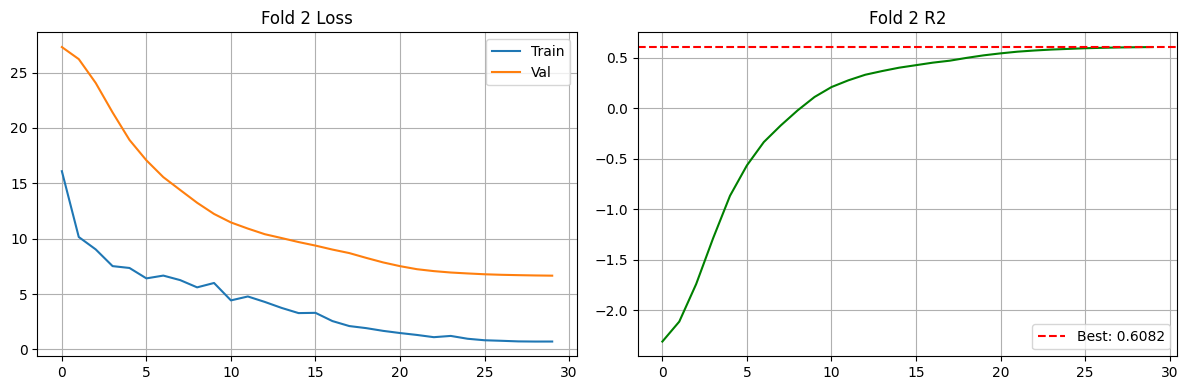


⏱️ Fold 2 completed in 1.84 hours

🚀 FOLD 3 / 4
Train: 275 | Val: 82
✅ Gradient Checkpointing enabled

Epoch 1/30


Train:   0%|          | 0/137 [00:00<?, ?it/s]

Valid:   0%|          | 0/41 [00:00<?, ?it/s]

  Loss: 18.0070/18.8212 | R2: -1.9030 | LR: 3.33e-05
  R2: G=-0.937 D=-0.558 C=-0.497 GDM=-1.979 T=-2.616
  ✅ Saved: /workspace/checkpoints/best_model_fold3.pth

Epoch 2/30


Train:   0%|          | 0/137 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/41 [00:00<?, ?it/s]

  Loss: 1.0419/3.3986 | R2: 0.8278 | LR: 1.69e-07
  R2: G=0.914 D=0.743 C=0.736 GDM=0.825 T=0.847

Epoch 30/30


Train:   0%|          | 0/137 [00:00<?, ?it/s]

Valid:   0%|          | 0/41 [00:00<?, ?it/s]

  Loss: 1.0307/3.4394 | R2: 0.8242 | LR: 0.00e+00
  R2: G=0.915 D=0.748 C=0.712 GDM=0.824 T=0.844

🏆 Fold 3 Best R2: 0.8319


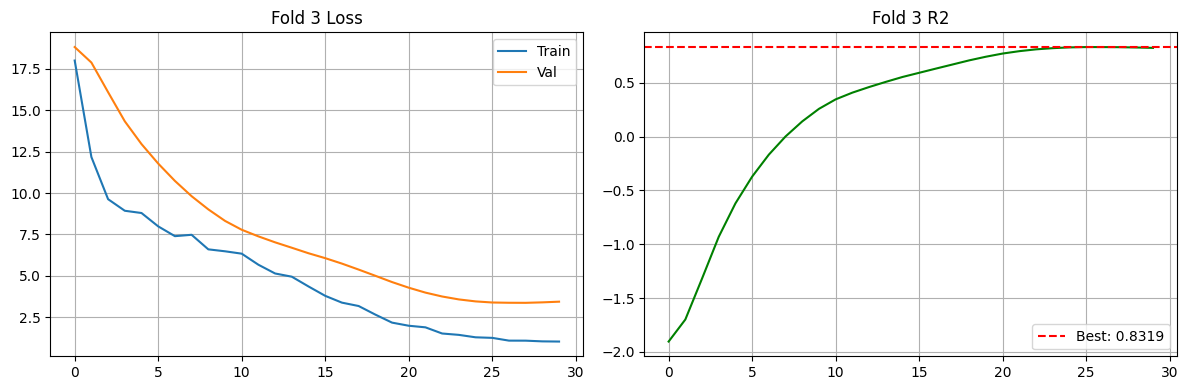


⏱️ Fold 3 completed in 1.75 hours

🚀 FOLD 4 / 4
Train: 281 | Val: 76
✅ Gradient Checkpointing enabled

Epoch 1/30


Train:   0%|          | 0/140 [00:00<?, ?it/s]

Valid:   0%|          | 0/38 [00:00<?, ?it/s]

  Loss: 17.7760/19.3686 | R2: -1.7081 | LR: 3.33e-05
  R2: G=-1.210 D=-0.579 C=-0.170 GDM=-1.773 T=-2.315
  ✅ Saved: /workspace/checkpoints/best_model_fold4.pth

Epoch 2/30


Train:   0%|          | 0/140 [00:00<?, ?it/s]

...

  Loss: 0.7064/5.0625 | R2: 0.6017 | LR: 1.69e-07
  R2: G=0.645 D=0.304 C=0.818 GDM=0.607 T=0.607

Epoch 30/30


Train:   0%|          | 0/140 [00:00<?, ?it/s]

IOStream.flush timed out
IOStream.flush timed out
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x75ad5a54d1c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
    if w.is_alive():Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x75ad5a54d1c0> 
    Traceback (most recent call last):
   File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1477, in __del__
 ^^    ^self._shutdown_workers()^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ ^ 
   File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a ch

Valid:   0%|          | 0/38 [00:00<?, ?it/s]

  Loss: 0.7300/5.0692 | R2: 0.6004 | LR: 0.00e+00
  R2: G=0.644 D=0.305 C=0.815 GDM=0.605 T=0.606

🏆 Fold 4 Best R2: 0.6037


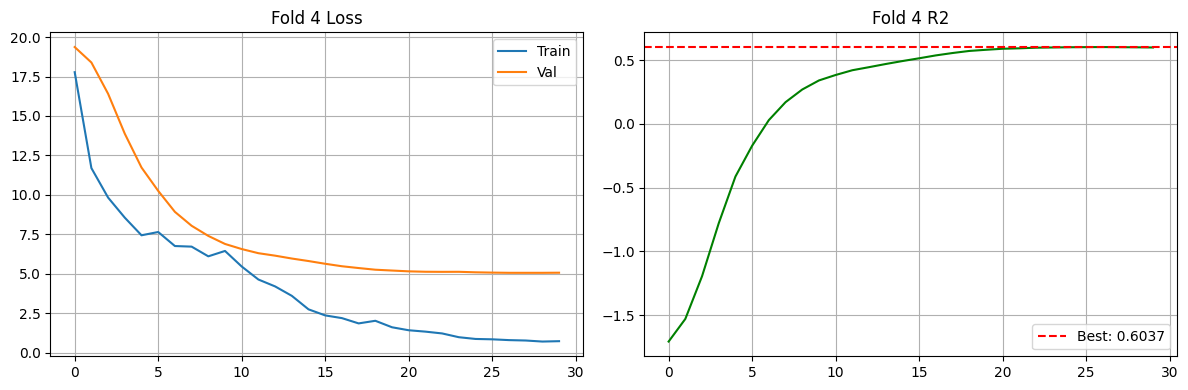


⏱️ Fold 4 completed in 1.77 hours

🎉 TRAINING COMPLETE!
  Fold 0: R2 = 0.6500 (1.79h)
  Fold 1: R2 = 0.3823 (1.79h)
  Fold 2: R2 = 0.6082 (1.84h)
  Fold 3: R2 = 0.8319 (1.75h)
  Fold 4: R2 = 0.6037 (1.77h)

⏱️ Total time: 8.93 hours
📁 Checkpoints saved to: /workspace/checkpoints


In [7]:
#@title 4.2 🚀 Train All Folds
print("=" * 60)
print("🚀 STARTING TRAINING - ALL 5 FOLDS")
print("=" * 60)
print(f"\n⏰ Estimated time: ~20 hours")
print(f"💰 Estimated cost: ~$8-15 (RTX 4090/A5000)")
print("\n" + "=" * 60)

fold_scores = []
start_time = time.time()

for fold in range(CFG.N_FOLDS):
    # Skip if already trained
    ckpt = CFG.CHECKPOINT_DIR / f"best_model_fold{fold}.pth"
    if ckpt.exists():
        size = ckpt.stat().st_size / 1024**3
        print(f"\n⏭️ Fold {fold} already exists ({size:.2f} GB) - skipping")
        continue
    
    fold_start = time.time()
    score = train_fold(fold, df_wide)
    fold_time = (time.time() - fold_start) / 3600
    
    fold_scores.append((fold, score, fold_time))
    print(f"\n⏱️ Fold {fold} completed in {fold_time:.2f} hours")

total_time = (time.time() - start_time) / 3600

print("\n" + "=" * 60)
print("🎉 TRAINING COMPLETE!")
print("=" * 60)
for fold, score, t in fold_scores:
    print(f"  Fold {fold}: R2 = {score:.4f} ({t:.2f}h)")
print(f"\n⏱️ Total time: {total_time:.2f} hours")
print(f"📁 Checkpoints saved to: {CFG.CHECKPOINT_DIR}")


## 5. 📥 Download Models

学習完了後、チェックポイントをダウンロードしてKaggleにアップロードします。

In [8]:
#@title 5.1 Verify Checkpoints
print("📁 Saved checkpoints:")
print("-" * 50)

total_size = 0
for fold in range(CFG.N_FOLDS):
    ckpt = CFG.CHECKPOINT_DIR / f"best_model_fold{fold}.pth"
    if ckpt.exists():
        size = ckpt.stat().st_size / 1024**3
        total_size += size
        print(f"  ✅ Fold {fold}: best_model_fold{fold}.pth ({size:.2f} GB)")
    else:
        print(f"  ❌ Fold {fold}: NOT FOUND")

print("-" * 50)
print(f"Total: {total_size:.2f} GB")


📁 Saved checkpoints:
--------------------------------------------------
  ✅ Fold 0: best_model_fold0.pth (3.17 GB)
  ✅ Fold 1: best_model_fold1.pth (3.17 GB)
  ✅ Fold 2: best_model_fold2.pth (3.17 GB)
  ✅ Fold 3: best_model_fold3.pth (3.17 GB)
  ✅ Fold 4: best_model_fold4.pth (3.17 GB)
--------------------------------------------------
Total: 15.83 GB


In [9]:
#@title 5.2 Create ZIP for Download
import os

zip_path = "/workspace/trained_models.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

print("📦 Creating zip file...")
!cd {CFG.CHECKPOINT_DIR} && zip -r {zip_path} best_model_fold*.pth

if os.path.exists(zip_path):
    size = os.path.getsize(zip_path) / 1024**3
    print(f"\n✅ Created: {zip_path} ({size:.2f} GB)")
    print("\n📥 Download:")
    print("   JupyterLabの左パネルで trained_models.zip を右クリック → Download")
else:
    print("❌ Failed to create zip")


📦 Creating zip file...
/bin/bash: line 1: zip: command not found
❌ Failed to create zip


In [10]:
#@title 5.3 Test Load Model
TEST_FOLD = 0

ckpt = CFG.CHECKPOINT_DIR / f"best_model_fold{TEST_FOLD}.pth"
if ckpt.exists():
    print(f"Testing fold {TEST_FOLD}...")
    
    # Create model without pretrained weights
    test_model = BiomassModel(CFG.BACKBONE, pretrained=False)
    test_model.load_state_dict(torch.load(ckpt, map_location="cpu"))
    
    test_model.eval()
    with torch.no_grad():
        dummy_left = torch.randn(1, 3, 512, 512)
        dummy_right = torch.randn(1, 3, 512, 512)
        out = test_model((dummy_left, dummy_right))
    
    print(f"✅ Output shape: {out.shape} (expected: [1, 5])")
    print("✅ Model loads correctly!")
    
    del test_model
    torch.cuda.empty_cache()
else:
    print(f"❌ {ckpt} not found")


Testing fold 0...
✅ Gradient Checkpointing enabled
✅ Output shape: torch.Size([1, 5]) (expected: [1, 5])
✅ Model loads correctly!
